## 1.Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

## 2. Load the Dataset

In [4]:
df = pd.read_csv('data/AirQualityUCI.csv',sep=';')
df = df.drop(columns=['Unnamed: 15','Unnamed: 16'])
y_target = 'PT08.S1(CO)'
df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"


In [5]:
feature_string = df.select_dtypes(include='object').columns.to_list()
kolom_tanggal = [col for col in feature_string if 'date' in col.lower() or 'time' in col.lower()]
kolom_object_lainnya = [col for col in feature_string if col not in kolom_tanggal]

for col in  kolom_object_lainnya:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

kolom_tanggal

['Date', 'Time']

In [6]:
df[kolom_tanggal[1]] = df[kolom_tanggal[1]].astype(str).str.replace('.',':',regex=False)
datetime_string = df[kolom_tanggal[0]] + ' ' + df[kolom_tanggal[1]]
df['datetime'] = pd.to_datetime(datetime_string,format='%d/%m/%Y %H:%M:%S', errors='coerce')

df = df.drop(columns=['Date', 'Time'])
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,datetime
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00


## 3. Dataset Overview

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CO(GT)         9357 non-null   float64       
 1   PT08.S1(CO)    9357 non-null   float64       
 2   NMHC(GT)       9357 non-null   float64       
 3   C6H6(GT)       9357 non-null   float64       
 4   PT08.S2(NMHC)  9357 non-null   float64       
 5   NOx(GT)        9357 non-null   float64       
 6   PT08.S3(NOx)   9357 non-null   float64       
 7   NO2(GT)        9357 non-null   float64       
 8   PT08.S4(NO2)   9357 non-null   float64       
 9   PT08.S5(O3)    9357 non-null   float64       
 10  T              9357 non-null   float64       
 11  RH             9357 non-null   float64       
 12  AH             9357 non-null   float64       
 13  datetime       9357 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(13)
memory usage: 1.0 MB


In [8]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,datetime
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,2004-09-21 16:00:00
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,2004-03-10 18:00:00
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,2004-06-16 05:00:00
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,2004-09-21 16:00:00
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,2004-12-28 03:00:00
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN


## 3.Missing & Duplicate Values Analysis

In [9]:
missing = pd.DataFrame({
    'Missing Count':df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum()/len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values(by='Missing Percentage',ascending=True)
print('Colmuns with Missing values')
missing

Colmuns with Missing values


,Missing Count,Missing Percentage
CO(GT),114,1.2
PT08.S1(CO),114,1.2
NMHC(GT),114,1.2
C6H6(GT),114,1.2
PT08.S2(NMHC),114,1.2
NOx(GT),114,1.2
PT08.S3(NOx),114,1.2
NO2(GT),114,1.2
PT08.S4(NO2),114,1.2
PT08.S5(O3),114,1.2


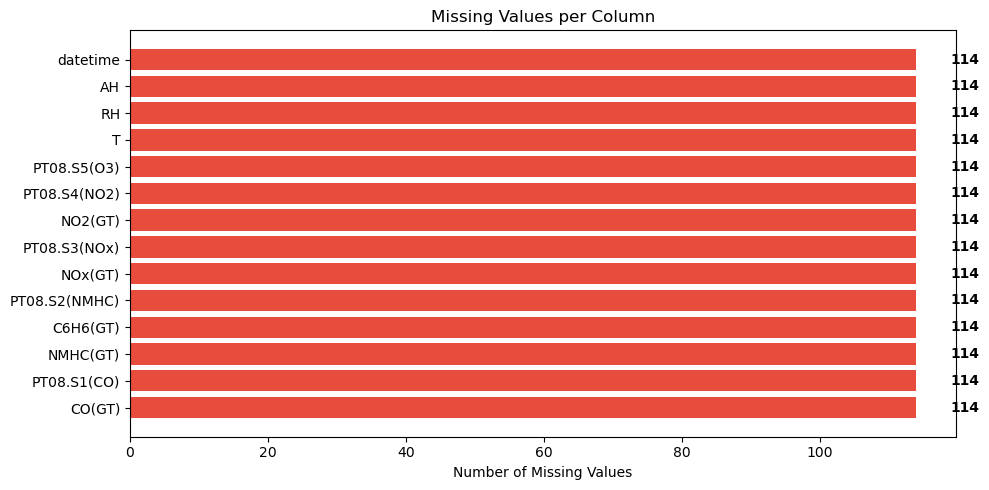

In [10]:
fig,ax = plt.subplots(figsize=(10,5))
ax.barh(missing.index,missing['Missing Count'].values,color='#e74c3c')
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")
for i,v in enumerate(missing['Missing Count'].values):
    if v > 0:
        ax.text(v+5,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
duplicate = pd.DataFrame({
    'Duplicate Count':df.duplicated().sum(),
    'Duplicate Percentage': (df.duplicated().sum()/len(df) * 100).round(2)
},index=['Total Dataset'])
duplicate = duplicate[duplicate['Duplicate Count'] > 0].sort_values(by='Duplicate Percentage',ascending=True)
print('Colmuns with Duplicate values')
duplicate

Colmuns with Duplicate values


,Duplicate Count,Duplicate Percentage
Total Dataset,113,1.19


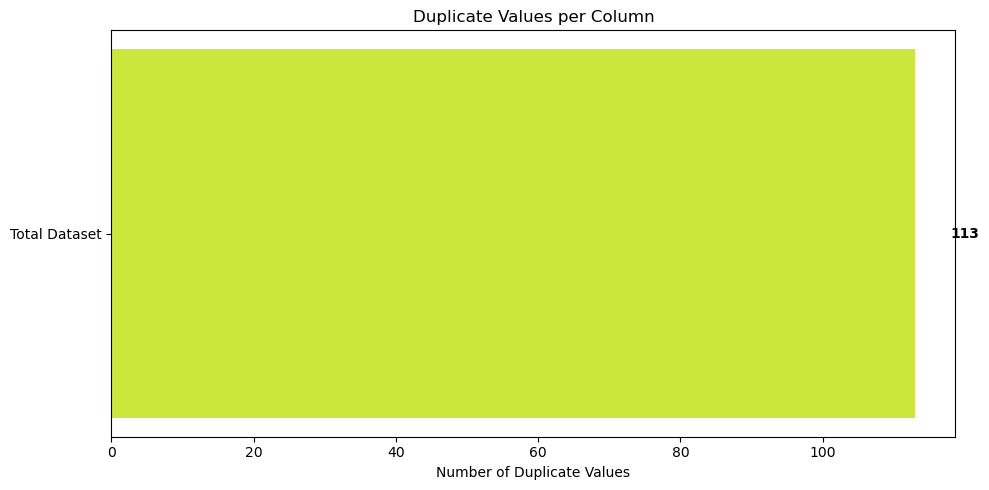

In [12]:
fig,ax = plt.subplots(figsize=(10,5))
ax.barh(duplicate.index,duplicate['Duplicate Count'].values,color="#cbe73c")
ax.set_xlabel("Number of Duplicate Values")
ax.set_title("Duplicate Values per Column")
for i,v in enumerate(duplicate['Duplicate Count'].values):
    if v > 0:
        ax.text(v+5,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

## 4.Target Variabel Distribution

d:\all-packmanager-app\miniconda3\envs\Hafidz29Python\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


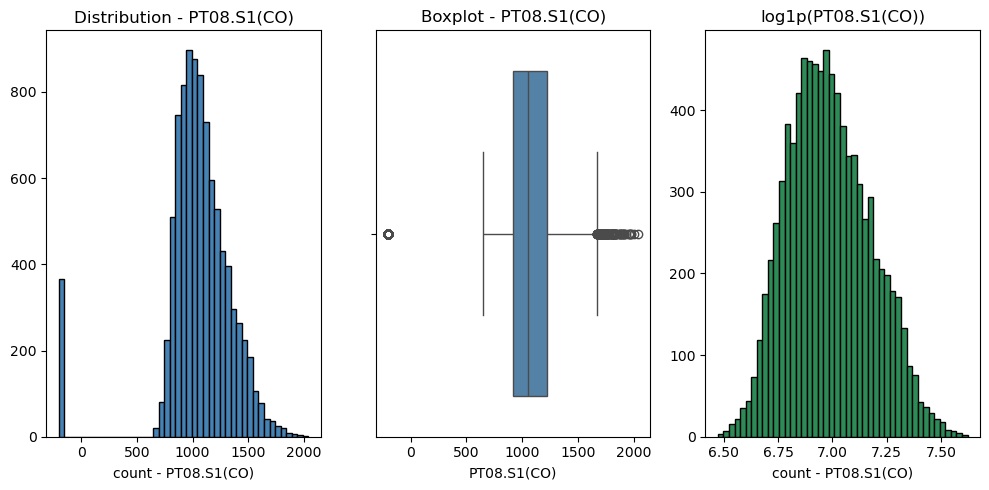

In [13]:
fig,axes = plt.subplots(1,3,figsize=(10,5))
axes[0].hist(df[y_target].dropna(),bins=45,color='steelblue',edgecolor='black')
axes[0].set_title(f'Distribution - {y_target}')
axes[0].set_xlabel(f'count - {y_target}')

sns.boxplot(x=df[y_target].dropna(),ax = axes[1],color='steelblue')
axes[1].set_title(f'Boxplot - {y_target}') 

axes[2].hist(np.log1p(df[y_target].dropna()),bins=45,color='seagreen',edgecolor='black')
axes[2].set_title(f'log1p({y_target})')
axes[2].set_xlabel(f'count - {y_target}')
plt.tight_layout()
plt.show()

In [14]:
describe = df[y_target].describe().round(3) #sudah berbentuk dataframe
y_stats = pd.DataFrame({
    y_target: [round(df[y_target].skew(), 3), round(df[y_target].kurtosis(), 3)]
},index=['Skewness', 'Kurtosis'])
df_stats = pd.concat([describe,y_stats]).T
df_stats

,count,mean,std,min,25%,50%,75%,max,Skewness,Kurtosis
PT08.S1(CO),9357.0,1048.99,329.833,-200.0,921.0,1053.0,1221.0,2040.0,-1.722,5.837


## 5. Univariat Analysis -- Numerical Features

In [15]:
feature_numerik = df.select_dtypes(include=[np.number]).columns.to_list()
ignored_features = [y_target, 'Id']
feature_numerik = [col for col in feature_numerik if col not in ignored_features]

print(f'Numeric features ({len(feature_numerik)}):')
print(feature_numerik[:30])

Numeric features (12):
['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


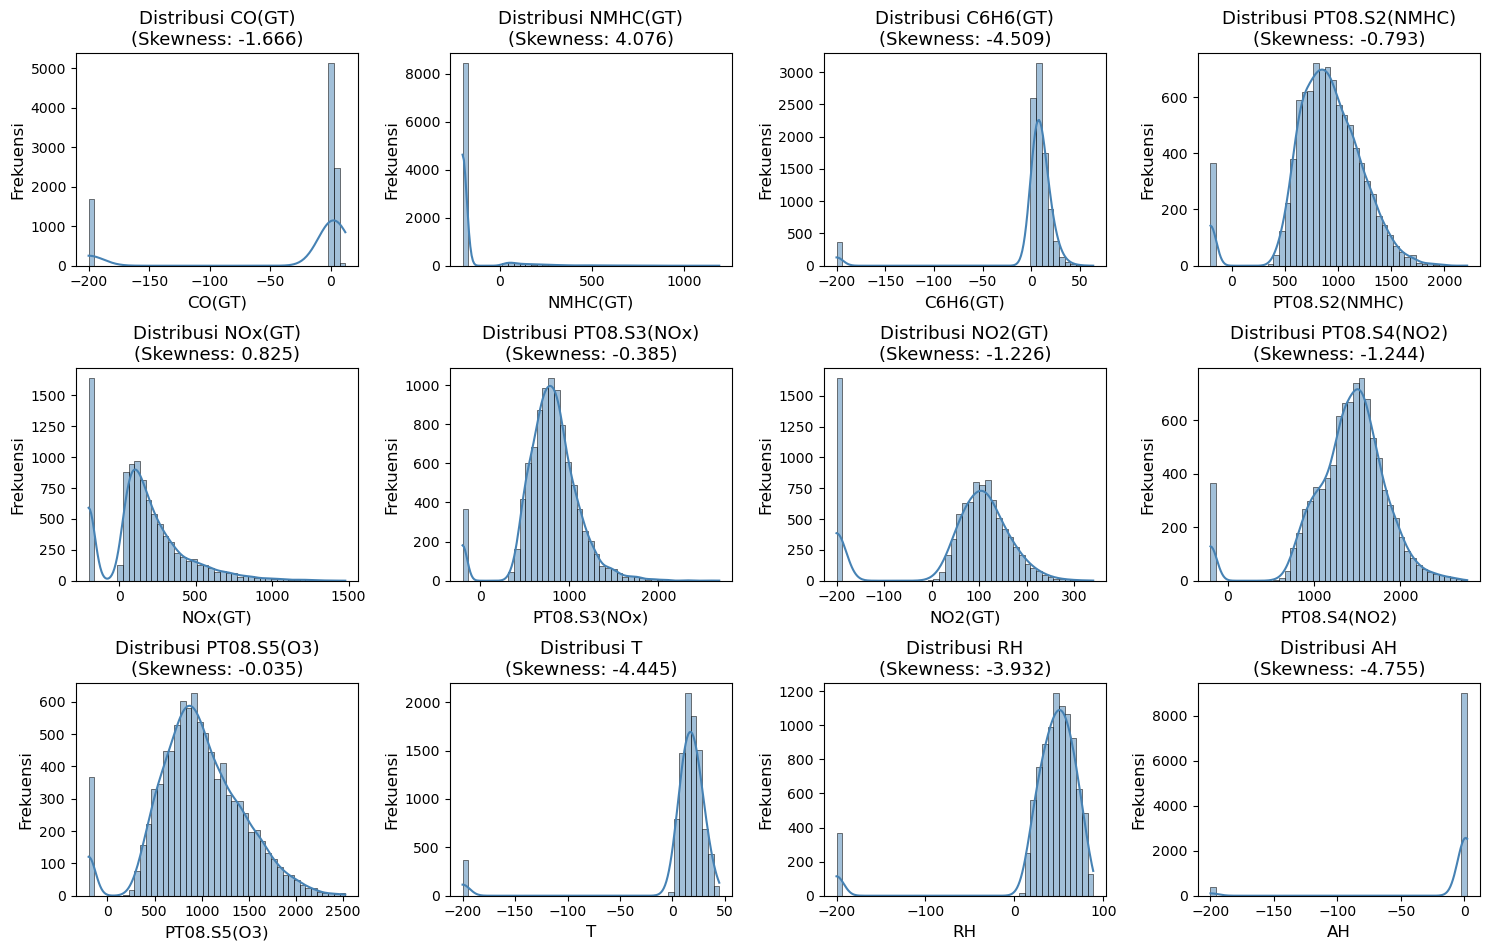

In [16]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i,feature in enumerate(feature_numerik):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature],ax=axes[i],kde=True,color='steelblue',edgecolor='black',bins=45)
    axes[i].set_title( f"Distribusi {feature}\n(Skewness: {feat_skew:.3f})",fontsize=13)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Frekuensi", fontsize=12)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 6.Bivariate Analysis -- Features VS Target

In [17]:
feature_numerik = df.select_dtypes(include=[np.number]).columns.to_list()
corrs_all = df[feature_numerik].corr()[y_target].abs().sort_values(ascending=False)
top_features = [x for x in corrs_all.index if x != y_target][:20]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
PT08.S2(NMHC)    0.933
PT08.S5(O3)      0.892
C6H6(GT)         0.853
PT08.S4(NO2)     0.845
AH               0.765
T                0.755
RH               0.745
NOx(GT)          0.278
NMHC(GT)         0.170
NO2(GT)          0.154
PT08.S3(NOx)     0.087
CO(GT)           0.041
Name: PT08.S1(CO), dtype: float64


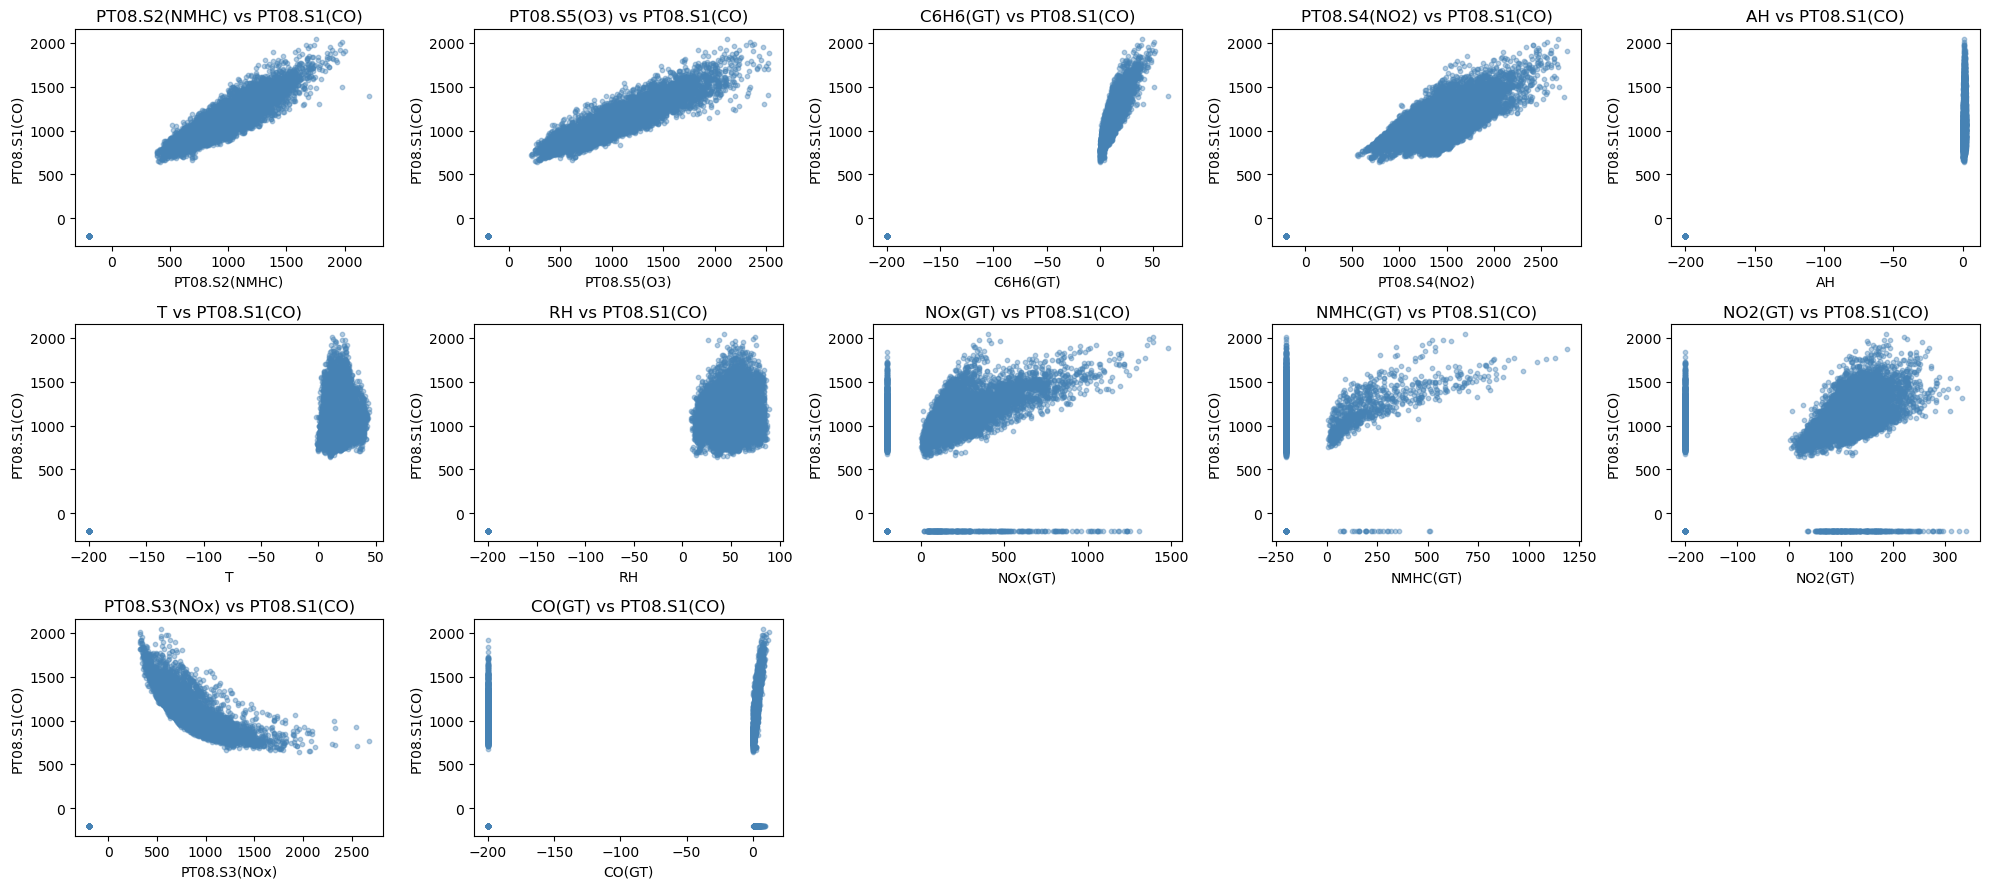

In [18]:
n_show = len(top_features)
n_cols = 5
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(20,3.0*nrows))
axes = axes.flatten()
for i,feature in enumerate(top_features):
    axes[i].scatter(df[feature],df[y_target],alpha=0.4,s=10,color='steelblue')
    axes[i].set_xlabel(feature); axes[i].set_ylabel(f'{y_target}')
    axes[i].set_title(f'{feature} vs {y_target}')
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 7.Multivariat Analysis

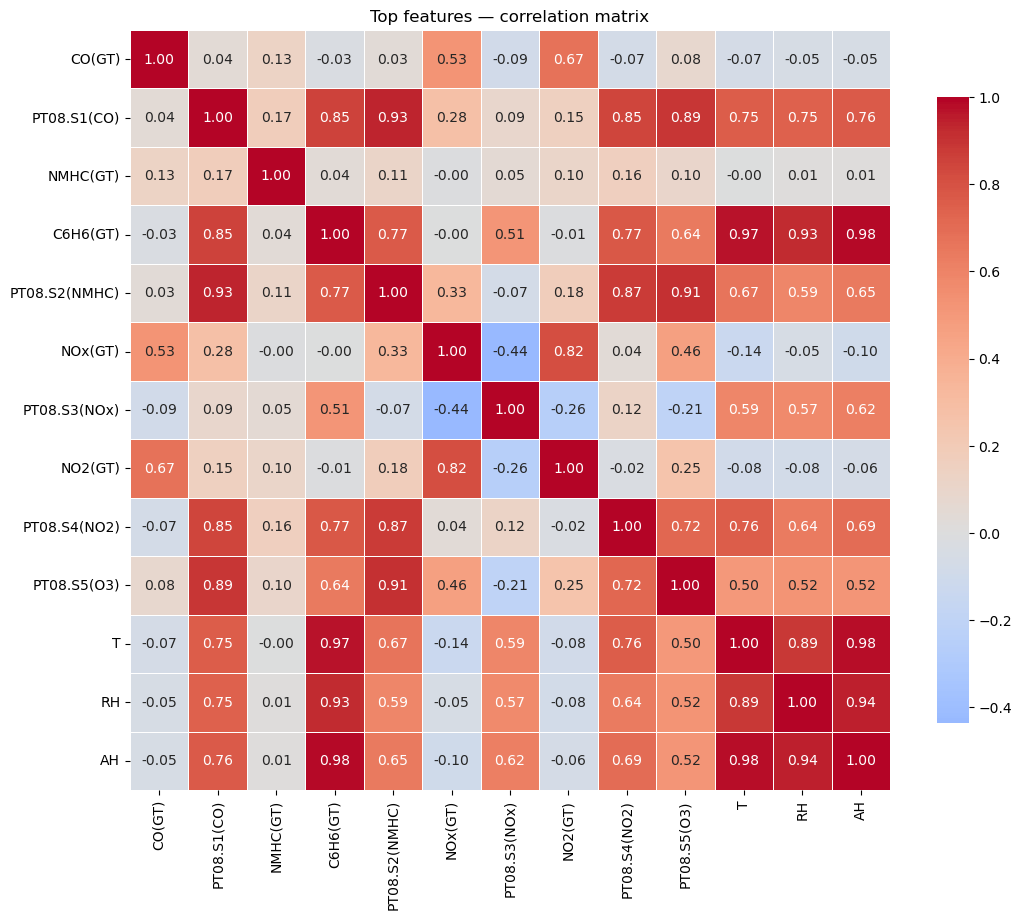

In [19]:
corr_matrix = df[feature_numerik].corr()
plt.figure(figsize=(11,10))
sns.heatmap(corr_matrix,annot=True,fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix')
plt.tight_layout()
plt.show()

## 8.Deep Analysis Feature Year

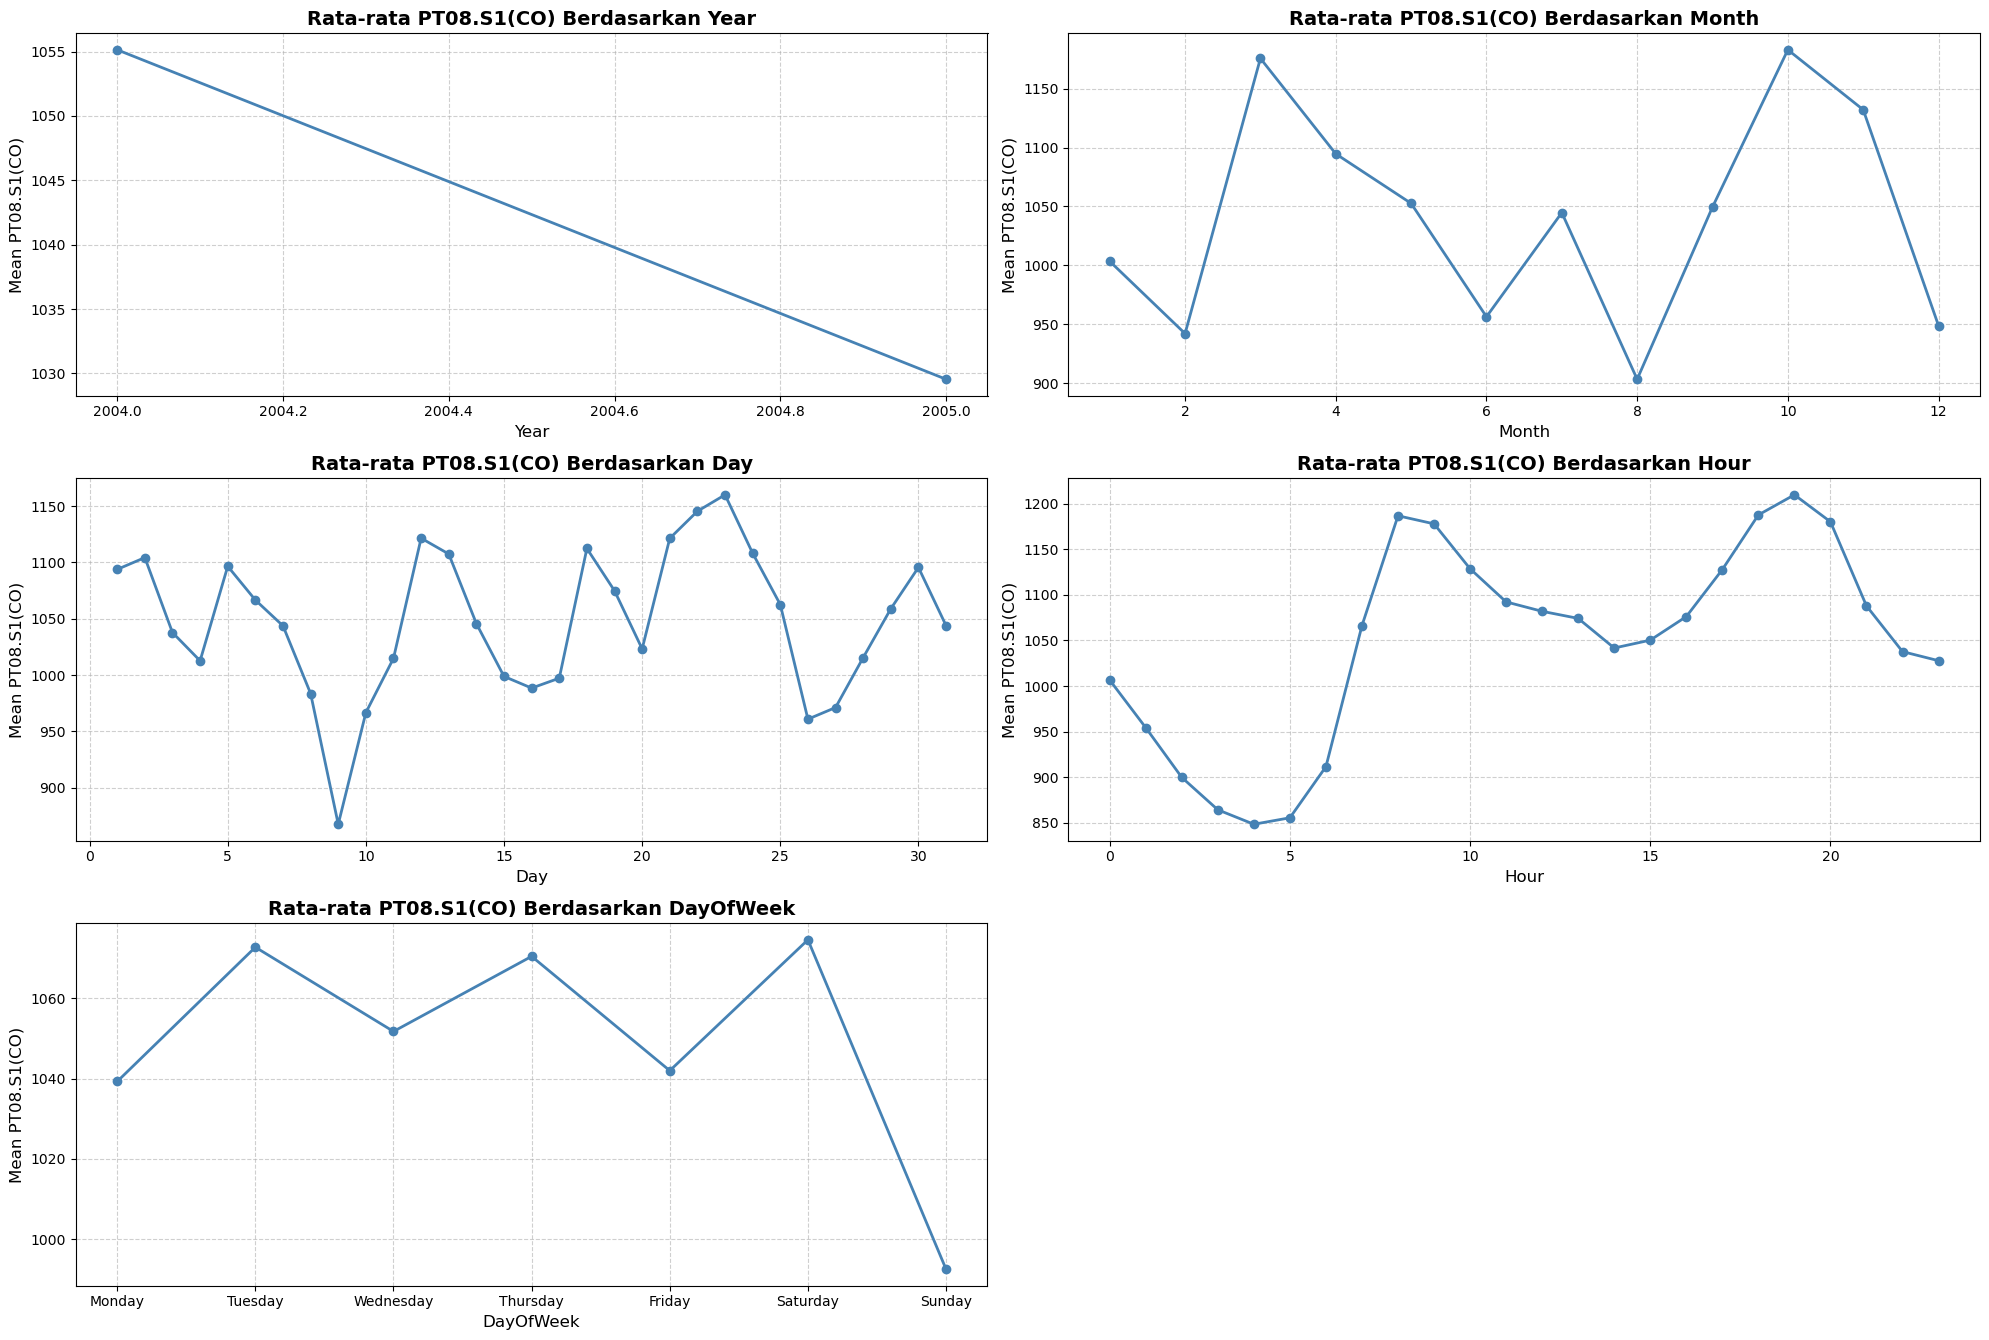

In [ ]:
df_copy = df.copy()

df_copy['Year'] = df_copy['datetime'].dt.year
df_copy['Month'] = df_copy['datetime'].dt.month
df_copy['Day'] = df_copy['datetime'].dt.day
df_copy['Hour'] = df_copy['datetime'].dt.hour
df_copy['DayOfWeek'] = df_copy['datetime'].dt.day_name()

features_waktu = ['Year', 'Month', 'Day', 'Hour', 'DayOfWeek']

n_show = len(features_waktu)
n_cols = 2
nrows = math.ceil(n_show / n_cols)

fig, axes = plt.subplots(nrows, n_cols, figsize=(20, 4.5 * nrows))
axes = axes.flatten()

for i, feature in enumerate(features_waktu):
    if feature == 'DayOfWeek':
        urutan_hari = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        data_plot = df_copy.groupby(feature)[y_target].mean().reindex(urutan_hari)
    else:
        data_plot = df_copy.groupby(feature)[y_target].mean()
    data_plot.plot(ax=axes[i], marker='o', color='steelblue', linewidth=2)
    axes[i].set_title(f'Rata-rata {y_target} Berdasarkan {feature}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel(f'Mean {y_target}', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

for j in range(n_show, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 9.Summary of Key Findings

In [28]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df[y_target].mean(), 2),
        round(df[y_target].median(), 2),
        round(df[y_target].std(), 2),
        round(df[y_target].min(), 2),
        round(df[y_target].max(), 2),
        round(df[y_target].skew(), 3),
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,9471
1,Total features,13
2,Target mean,1048.99
3,Target median,1053.0
4,Target stddev,329.83
5,Target min,-200.0
6,Target max,2040.0
7,Target skewness,-1.722
8,Top correlated feature,PT08.S2(NMHC)
9,Top correlation value,0.933
